# Model Sources: Unified Discovery, Download & Visualization

This notebook downloads a representative HEC-RAS model from each source, initializes it with ras-commander, and captures a RASMapper screenshot.

| Source | Representative Model | HEC-RAS Version | Type |
|--------|---------------------|-----------------|------|
| USGS ScienceBase | Kalamazoo River, MI | 6.6 | 2D Unsteady |
| Minnesota DNR | Chester Creek | 5.0.3 | 1D Steady |
| Indiana DNR | Fall Creek Trail Bridge | 5.0.7 | 1D Steady |
| Colorado CHAMP | Henson Creek | 4.1.0 | 1D Steady |
| FEMA eBFE/BLE | Spring Creek | 5.0.7 | 2D Unsteady |
| Harris County M3 | Brays Bayou | 3.0.1 | 1D Steady |

**Requirements**: HEC-RAS installed (for RASMapper screenshots), internet connection (for API queries).

In [1]:
from pathlib import Path
import os
import sys
import time

try:
    from ras_commander import init_ras_project, RasMap
except ImportError:
    sys.path.insert(0, str(Path.cwd().parent))
    from ras_commander import init_ras_project, RasMap

import pandas as pd
from IPython.display import Image, display

from ras_commander.sources.catalog import ModelCatalog, get_catalog
from ras_commander.sources.base import (
    ModelMetadata, ModelType, ModelFilter,
    SourceStatus, DownloadResult,
)
from ras_commander.sources.federal.usgs_sciencebase import UsgsScienceBase
from ras_commander.sources.state.mn_dnr import MinnesotaDnrModels
from ras_commander.sources.state.in_dnr import IndianaDnrModels
from ras_commander.sources.state.co_champ import ColoradoChampModels
from ras_commander.sources.federal.noaa_ras2fim import NoaaRas2fimModels
from ras_commander.sources.federal import RasEbfeModels
from ras_commander.sources.county import M3Model

# Shared workspace
DOWNLOAD_ROOT = Path(os.environ.get(
    "RAS_COMMANDER_MODEL_SOURCES_ROOT",
    r"H:\Testing\Model_Sources_Showcase"
))
SCREENSHOT_DIR = DOWNLOAD_ROOT / "screenshots"
DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)
SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Download root: {DOWNLOAD_ROOT}")
print(f"Screenshots:   {SCREENSHOT_DIR}")

2026-06-11 14:39:14 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.


Download root: <model-sources-workspace>
Screenshots:   <model-sources-workspace>\screenshots


In [2]:
def find_ras_prj(folder: Path) -> Path:
    """Find the primary HEC-RAS .prj file in a folder (not CRS projection files)."""
    for prj in sorted(folder.rglob("*.prj")):
        try:
            first_line = prj.read_text(encoding="utf-8", errors="ignore").split("\n")[0]
            if first_line.startswith("Proj Title="):
                return prj
        except Exception:
            continue
    return None


def screenshot_and_display(
    prj_path: Path,
    label: str,
    ras_version: str,
    delay: float = 8.0,
) -> Path:
    """Take a RASMapper screenshot and display it inline."""
    png_path = SCREENSHOT_DIR / f"{label}.png"
    print(f"Capturing RASMapper screenshot for {label}...")
    print(f"  .prj: {prj_path}")
    print(f"  RAS version: {ras_version}")

    try:
        result = RasMap.screenshot_model(
            ras_project_path=prj_path,
            output_path=png_path,
            delay_seconds=delay,
            ras_version=ras_version,
        )
    except FileNotFoundError as exc:
        print(f"  Skipped (no .rasmap file): {exc}")
        return None
    except Exception as exc:
        print(f"  Screenshot failed: {exc}")
        return None

    if result and result.exists() and result.stat().st_size > 0:
        print(f"  Saved: {result} ({result.stat().st_size / 1024:.1f} KB)")
        display(Image(filename=str(result), width=800))
        return result
    else:
        print(f"  Screenshot capture failed.")
        return None


print("Helper functions ready.")

Helper functions ready.


## Unified Catalog

The `ModelCatalog` auto-registers all available sources. Cross-source search with a single call.

In [3]:
catalog = get_catalog()

print("Registered sources:")
for name in catalog.list_sources(include_unavailable=True):
    status = catalog._source_status.get(name, SourceStatus.UNAVAILABLE)
    print(f"  {name}: {status.value}")

print("\nCross-source search: 'Creek' (limit 3 per source)")
creek_models = catalog.search_models(location="Creek", limit_per_source=3)
print(f"Found {len(creek_models)} models:\n")
for m in creek_models:
    print(f"  [{m.source_name}] {m.name} -- {m.model_type.value}")

2026-06-11 14:39:19 - ras_commander.sources.catalog - INFO - Found 2 models from USGS ScienceBase


2026-06-11 14:39:19 - ras_commander.sources.catalog - INFO - Found 0 models from Minnesota DNR


Registered sources:
  USGS ScienceBase: available
  Minnesota DNR: available
  Indiana DNR: available
  Colorado CHAMP: available
  NOAA ras2fim: requires_auth
  FEMA eBFE/BLE: available

Cross-source search: 'Creek' (limit 3 per source)


2026-06-11 14:39:20 - ras_commander.sources.catalog - INFO - Found 0 models from Indiana DNR


2026-06-11 14:39:22 - ras_commander.sources.state.co_champ - INFO - Found 0 models in CHAMP catalog


2026-06-11 14:39:22 - ras_commander.sources.catalog - INFO - Found 0 models from Colorado CHAMP


2026-06-11 14:39:22 - ras_commander.sources.catalog - INFO - Found 0 models from NOAA ras2fim


2026-06-11 14:39:22 - ras_commander.sources.catalog - INFO - Found 1 models from FEMA eBFE/BLE


Found 3 models:

  [USGS ScienceBase] Kalamazoo River, MI -- 2D unsteady
  [USGS ScienceBase] St. Joseph River, Elkhart, IN -- 1D steady
  [FEMA eBFE/BLE] SpringCreek_12040102 -- 2D unsteady


---
## Source 1: USGS ScienceBase -- Kalamazoo River, MI

Peer-reviewed 2D unsteady model (HEC-RAS 6.6, ~3 GB). DOI: 10.5066/P13CPA5B.

21 plans with HDF outputs, ADCP velocity and WSE calibration data.

In [4]:
# List ScienceBase catalog
sb_models = UsgsScienceBase.list_catalog_models()
for m in sb_models:
    print(f"{m.name} -- {m.model_type.value}, v{m.hecras_version}, DOI: {m.doi}")

Kalamazoo River, MI -- 2D unsteady, v6.6, DOI: 10.5066/P13CPA5B
St. Joseph River, Elkhart, IN -- 1D steady, v4.10, DOI: 10.5066/F7QZ2836


In [5]:
# Download Kalamazoo River (USGS ScienceBase) — ~3 GB, may take several minutes
sb_result = UsgsScienceBase.download_model(
    "kalamazoo",
    output_dir=DOWNLOAD_ROOT / "usgs",
)
sb_prj = find_ras_prj(sb_result) if sb_result else None
print(f"USGS prj: {sb_prj}")

USGS prj: <model-sources-workspace>\usgs\kalamazoo\hec_ras_model\kalamazoo_trowbridg.prj


Capturing RASMapper screenshot for 01_USGS_ScienceBase_Kalamazoo...
  .prj: <model-sources-workspace>\usgs\kalamazoo\hec_ras_model\kalamazoo_trowbridg.prj
  RAS version: 7.0


2026-06-11 14:39:25 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec-ras-install>\7.0\Ras.exe via filesystem (x86)


2026-06-11 14:39:25 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec-ras-install>\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-11 14:39:25 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at <hec-ras-install>\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-06-11 14:39:25 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at <hec-ras-install>\6.6\Ras.exe via filesystem (x86)


...

2026-06-11 14:39:25 - ras_commander.RasUtils - INFO - Discovered 20 installed HEC-RAS version(s)


2026-06-11 14:39:25 - ras_commander.RasPrj - INFO - HEC-RAS 7.0 found via version discovery: <hec-ras-install>\7.0\Ras.exe


2026-06-11 14:39:40 - ras_commander.gui.screenshots - INFO - Screenshot saved: <model-sources-workspace>\screenshots\01_USGS_ScienceBase_Kalamazoo.png


2026-06-11 14:39:40 - ras_commander.RasMap - INFO - Screenshot saved to <model-sources-workspace>\screenshots\01_USGS_ScienceBase_Kalamazoo.png


  Saved: <model-sources-workspace>\screenshots\01_USGS_ScienceBase_Kalamazoo.png (424.5 KB)


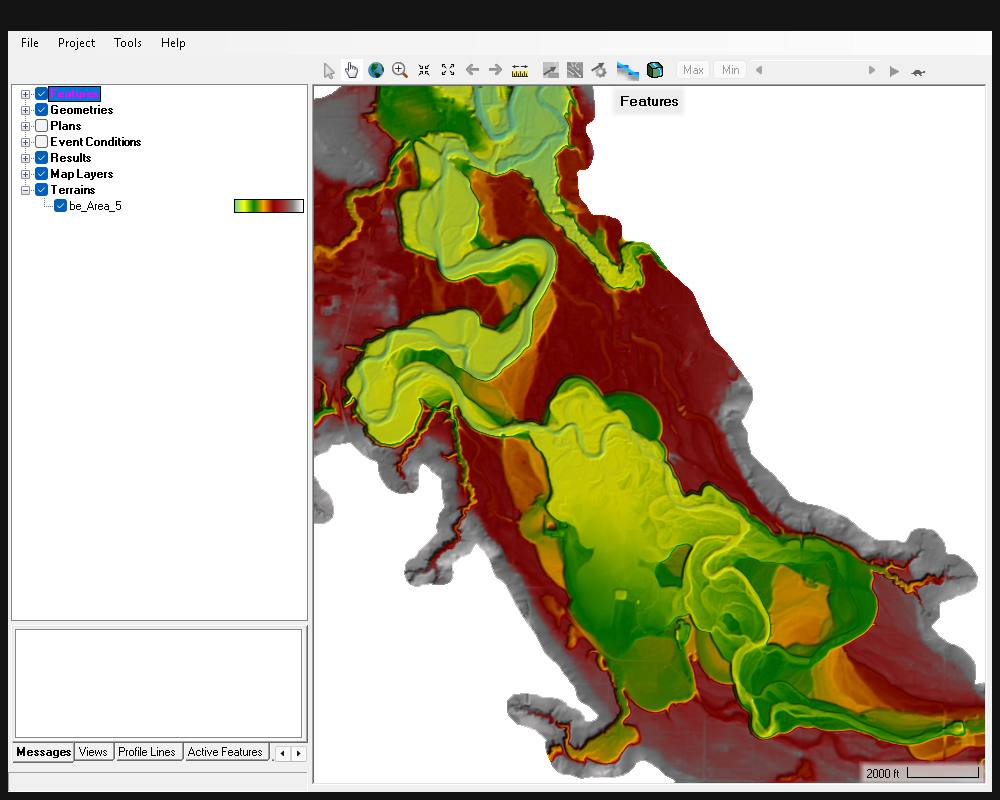

In [6]:
if sb_prj:
    screenshot_and_display(sb_prj, "01_USGS_ScienceBase_Kalamazoo", ras_version="7.0")

---
## Source 2: Minnesota DNR -- Chester Creek

~2,384 FEMA floodplain HEC-RAS models across 67 MN counties, all 1D steady-state.

Chester Creek (St. Louis County) is a multi-geometry model built with HEC-RAS 5.0.3.

> **Note**: MN DNR models are 1D steady-state (HEC-RAS 4.x/5.x), which predate the RASMapper `.rasmap` convention. Screenshots are not available for this source.

In [7]:
# Query MN DNR catalog
mn_counties = MinnesotaDnrModels.list_counties()
print(f"MN DNR: {len(mn_counties)} counties")

mn_models = MinnesotaDnrModels.list_models(location="St. Louis", limit=5)
print(f"St. Louis County models (up to 5): {len(mn_models)}")
for m in mn_models:
    print(f"  {m.name} -- {m.source_id}")

MN DNR: 67 counties
St. Louis County models (up to 5): 0


In [8]:
# Download Chester Creek (MN DNR)
# Search the full catalog by name — location-based filtering is unreliable
# when the API county name format changes.
mn_all = MinnesotaDnrModels.list_models(limit=100)
chester = [m for m in mn_all if "Chester" in m.name]
mn_prj = None
if chester:
    mn_model = chester[0]
elif mn_models:
    mn_model = mn_models[0]
else:
    mn_model = mn_all[0] if mn_all else None

if mn_model:
    mn_result = MinnesotaDnrModels.download_model(
        mn_model.source_id,
        output_folder=DOWNLOAD_ROOT / "mn_dnr",
    )
    mn_prj = find_ras_prj(mn_result.model_path) if mn_result and mn_result.success else None
    print(f"MN DNR model: {mn_model.name}")
else:
    print("MN DNR: no models available")
print(f"MN DNR prj: {mn_prj}")

MN DNR model: trott_brook_trib1_ras
MN DNR prj: <model-sources-workspace>\mn_dnr\trott_brook_trib1_ras\trott_brook_trib1_ras.prj


In [9]:
if mn_prj:
    screenshot_and_display(mn_prj, "02_MN_DNR_Chester_Creek", ras_version="7.0")

Capturing RASMapper screenshot for 02_MN_DNR_Chester_Creek...
  .prj: <model-sources-workspace>\mn_dnr\trott_brook_trib1_ras\trott_brook_trib1_ras.prj
  RAS version: 7.0
  Skipped (no .rasmap file): RASMapper file not found: <model-sources-workspace>\mn_dnr\trott_brook_trib1_ras\trott_brook_trib1_ras.rasmap


---
## Source 3: Indiana DNR -- Fall Creek Trail Bridge

~11,400 models across 92 IN counties (largest single state source).

Fall Creek Trail Bridge (Hamilton County) is a 1D steady model with 4 plans, built with HEC-RAS 5.0.7.

> **Note**: IN DNR models are 1D steady-state (HEC-RAS 4.x/5.x), which predate the RASMapper `.rasmap` convention. Screenshots are not available for this source.

In [10]:
# Query IN DNR catalog
in_counties = IndianaDnrModels.list_counties()
print(f"IN DNR: {len(in_counties)} counties")

in_models = IndianaDnrModels.list_models(location="Hamilton", limit=5)
print(f"Hamilton County models (up to 5): {len(in_models)}")
for m in in_models:
    print(f"  {m.name} -- ID: {m.source_id}, {m.model_type.value}")

IN DNR: 92 counties


Hamilton County models (up to 5): 5
  Long Branch - Hamilton Co - (PERMIT) -- ID: 4770, 1D steady
  Little Cicero Creek - Hamilton Co - (FARA) -- ID: 5709, 1D steady
  Taylor Creek - Hamilton Co - (APPROX_ZoneA) -- ID: 5884, 1D steady
  Taylor Creek - Hamilton Co - (APPROX_ZoneA) -- ID: 5884, 1D steady
  Bennett Ditch - Hamilton Co - (APPROX_ZoneA) -- ID: 5892, 1D steady


In [11]:
# Download Fall Creek Trail Bridge (IN DNR — Hamilton County)
fall_creek = [m for m in IndianaDnrModels.list_models(location="Hamilton") if "Fall Creek" in m.name]
in_model = fall_creek[0] if fall_creek else in_models[0]
in_result = IndianaDnrModels.download_model(
    in_model.source_id,
    output_folder=DOWNLOAD_ROOT / "in_dnr",
)
in_prj = find_ras_prj(in_result.model_path) if in_result and in_result.success else None
print(f"IN DNR prj: {in_prj}")

IN DNR prj: <model-sources-workspace>\in_dnr\IN_DNR_6234\FallCreek.prj


In [12]:
if in_prj:
    screenshot_and_display(in_prj, "03_IN_DNR_Fall_Creek", ras_version="7.0")

Capturing RASMapper screenshot for 03_IN_DNR_Fall_Creek...
  .prj: <model-sources-workspace>\in_dnr\IN_DNR_6234\FallCreek.prj
  RAS version: 7.0
  Skipped (no .rasmap file): RASMapper file not found: <model-sources-workspace>\in_dnr\IN_DNR_6234\FallCreek.rasmap


---
## Source 4: Colorado CHAMP

Small CWCB CHAMP catalog (~3 downloadable entries). Catalog contents change over time; some entries are non-HEC-RAS studies (HMS hydrology models, shapefiles only). The download cell iterates through available entries until one containing a valid HEC-RAS project is found.

In [13]:
# Query CHAMP catalog
co_models = ColoradoChampModels.list_models()
print(f"Colorado CHAMP models: {len(co_models)}")
for m in co_models:
    size = f"{m.file_size_mb:.1f} MB" if m.file_size_mb else "unknown"
    print(f"  {m.name} -- {m.model_type.value} ({size})")

2026-06-11 14:39:43 - ras_commander.sources.state.co_champ - INFO - Found 3 models in CHAMP catalog


Colorado CHAMP models: 3
  CHAMP Y1 Hydro TSDN - Big Thompson -- 1D steady (31.9 MB)
  St. Vrain Hydraulics TSDN -- 1D steady (717.2 MB)
  Lake City/Hinsdale County Hydraulic Models -- 1D steady (0.6 MB)


In [14]:
# Download first CO CHAMP entry that contains a HEC-RAS project.
# Some catalog entries are non-HEC-RAS studies (HMS models, shapefiles only);
# iterate until find_ras_prj() succeeds.
co_prj = None
for co_model in co_models:
    co_result = ColoradoChampModels.download_model(
        co_model.source_id,
        output_folder=DOWNLOAD_ROOT / "co_champ",
    )
    if co_result and co_result.success:
        co_prj = find_ras_prj(co_result.model_path)
        if co_prj:
            print(f"CO CHAMP model: {co_model.name}")
            break
        print(f"  {co_model.name}: no HEC-RAS project found, trying next")
if not co_prj:
    print("CO CHAMP: no models with HEC-RAS content found in catalog")
print(f"CO CHAMP prj: {co_prj}")

  CHAMP Y1 Hydro TSDN - Big Thompson: no HEC-RAS project found, trying next


CO CHAMP model: St. Vrain Hydraulics TSDN
CO CHAMP prj: <model-sources-workspace>\co_champ\St_Vrain_Hydraulics_TSDN\StVrain_RiskMAP_HydraulicsTSDN\Stream_Name\NSVC_RM2\Simulations\NSVC_RM.prj


In [15]:
if co_prj:
    screenshot_and_display(co_prj, "04_CO_CHAMP_Henson_Creek", ras_version="7.0")

2026-06-11 14:40:30 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec-ras-install>\7.0\Ras.exe via filesystem (x86)


2026-06-11 14:40:30 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec-ras-install>\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-11 14:40:30 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at <hec-ras-install>\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-06-11 14:40:30 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at <hec-ras-install>\6.6\Ras.exe via filesystem (x86)


2026-06-11 14:40:30 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at <hec-ras-install>\6.5\Ras.exe via filesystem (x86)


...

2026-06-11 14:40:30 - ras_commander.RasPrj - INFO - HEC-RAS 7.0 found via version discovery: <hec-ras-install>\7.0\Ras.exe


Capturing RASMapper screenshot for 04_CO_CHAMP_Henson_Creek...
  .prj: <model-sources-workspace>\co_champ\St_Vrain_Hydraulics_TSDN\StVrain_RiskMAP_HydraulicsTSDN\Stream_Name\NSVC_RM2\Simulations\NSVC_RM.prj
  RAS version: 7.0


2026-06-11 14:40:39 - ras_commander.gui.screenshots - INFO - Screenshot saved: <model-sources-workspace>\screenshots\04_CO_CHAMP_Henson_Creek.png


2026-06-11 14:40:39 - ras_commander.RasMap - INFO - Screenshot saved to <model-sources-workspace>\screenshots\04_CO_CHAMP_Henson_Creek.png


  Saved: <model-sources-workspace>\screenshots\04_CO_CHAMP_Henson_Creek.png (29.1 KB)


---
## Source 5: FEMA eBFE/BLE -- Spring Creek

Large 2D unsteady models from FEMA's BLE program. Spring Creek (HUC 12040102) is organized via `RasEbfeModels.organize_model()` into the standard delivery format.

See notebooks 950-957 for detailed eBFE workflows.

In [16]:
# List available eBFE models
seen = set()
for alias, canonical in sorted(RasEbfeModels._MODEL_ALIASES.items()):
    if canonical not in seen:
        seen.add(canonical)
        print(f"  {canonical}")
print(f"\nTotal eBFE models: {len(seen)}")

  lower-ouachita-bayou-deloutre
  bayou-darbonne
  lower-ouachita
  boeuf
  amite
  tickfaw
  lake-maurepas
  spring-river
  eleven-point
  spring-creek
  north-galveston-bay
  lower-brazos
  lower-colorado-cummins
  upper-guadalupe
  rio-hondo

Total eBFE models: 15


In [17]:
# Organize Spring Creek eBFE model (downloads + fixes broken paths automatically)
ebfe_result = RasEbfeModels.download_model(
    "spring-creek",
    output_folder=DOWNLOAD_ROOT / "ebfe",
)
if ebfe_result.success and ebfe_result.model_path:
    ebfe_ras_dir = ebfe_result.model_path / "RAS Model"
    ebfe_prj = find_ras_prj(ebfe_ras_dir) or find_ras_prj(ebfe_result.model_path)
else:
    ebfe_prj = None
print(f"eBFE prj: {ebfe_prj}")

Organizing Spring Creek (12040102) - Pattern 3a
Source: ebfe_downloads\12040102_Models_extracted
Output: <model-sources-workspace>\ebfe\SpringCreek_12040102

Source data not found - downloading from eBFE S3...

  URL: https://ebfedata.s3.amazonaws.com/12040102_Spring/12040102_Models.zip
  Destination: ebfe_downloads\12040102_Models.zip


    12040102_Models.zip:   0%|          | 0.00/10.4G [00:00<?, ?B/s]

  ✓ Downloaded 10.4 GB

Extracting Spring Creek Models (9.7 GB)...


  Extracting:   0%|          | 0.00/10.4G [00:00<?, ?B/s]

  ✓ Extracted to: ebfe_downloads\12040102_Models_extracted
[1/5] Extracting nested _Final.zip...
  Extracting 9.67 GB nested zip (may take 5-10 minutes)...


...

2026-06-11 14:47:28 - ras_commander.RasUtils - INFO - Found 1 valid HEC-RAS project folders


  ✓ Corrected 8 DSS path(s)
  ✓ Corrected 0 terrain path(s)
  ✓ Standardized 1 RAS project folder(s)

[6/6] Validating DSS files...
  Found 2 DSS file(s)

  Validating: Spring.dss
Configuring Java VM for DSS operations...


  Found Java: <hec-install>\HEC-Vortex\0.13.3\jre
[OK] Java VM configured


    Pathnames: 692
    ✓ Format OK (0 warnings)

  Validating: Spring.dss


    Pathnames: 692
    ✓ Format OK (0 warnings)

✓ Spring Creek organized to: <model-sources-workspace>\ebfe\SpringCreek_12040102

See <model-sources-workspace>\ebfe\SpringCreek_12040102\agent\model_log.md for details
eBFE prj: <model-sources-workspace>\ebfe\SpringCreek_12040102\RAS Model\Spring.prj


Capturing RASMapper screenshot for 05_eBFE_Spring_Creek...
  .prj: <model-sources-workspace>\ebfe\SpringCreek_12040102\RAS Model\Spring.prj
  RAS version: 7.0


2026-06-11 14:47:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at <hec-ras-install>\7.0\Ras.exe via filesystem (x86)


2026-06-11 14:47:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at <hec-ras-install>\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-11 14:47:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 4 at <hec-ras-install>\6.7 Beta 4\Ras.exe via filesystem (x86)


2026-06-11 14:47:37 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.6 at <hec-ras-install>\6.6\Ras.exe via filesystem (x86)


...

2026-06-11 14:47:37 - ras_commander.RasUtils - INFO - Discovered 20 installed HEC-RAS version(s)


2026-06-11 14:47:37 - ras_commander.RasPrj - INFO - HEC-RAS 7.0 found via version discovery: <hec-ras-install>\7.0\Ras.exe


2026-06-11 14:47:48 - ras_commander.gui.screenshots - INFO - Screenshot saved: <model-sources-workspace>\screenshots\05_eBFE_Spring_Creek.png


2026-06-11 14:47:48 - ras_commander.RasMap - INFO - Screenshot saved to <model-sources-workspace>\screenshots\05_eBFE_Spring_Creek.png


  Saved: <model-sources-workspace>\screenshots\05_eBFE_Spring_Creek.png (357.9 KB)


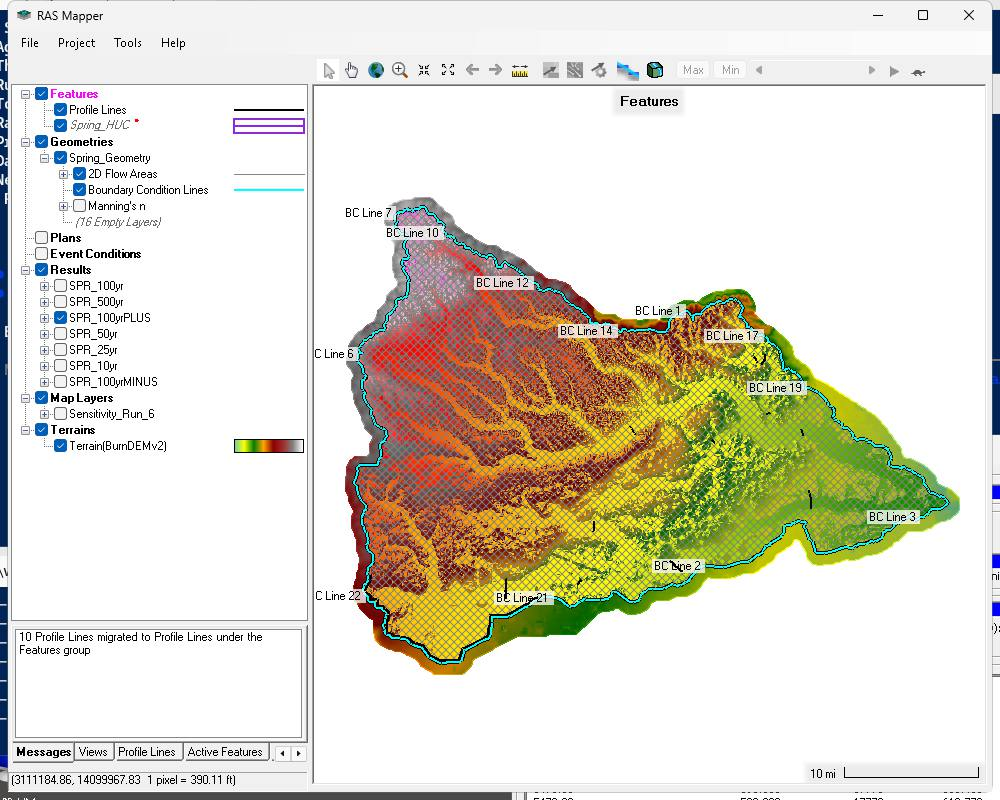

In [18]:
if ebfe_prj:
    screenshot_and_display(ebfe_prj, "05_eBFE_Spring_Creek", ras_version="7.0")

---
## Source 6: Harris County M3 -- Brays Bayou

20 FEMA-effective H&H models for Houston-area watersheds. All 1D steady (HEC-RAS 3.0.1).

> **Note**: HEC-RAS 3.0.1 predates RASMapper -- no `.rasmap` file is included and screenshots are not available for this source.

In [19]:
# List M3 models
m3_df = M3Model.list_models(as_dataframe=True)
print(f"Harris County M3 Models: {len(m3_df)}\n")
print(m3_df[['name', 'description', 'effective_date', 'size_gb']].to_string(index=True))

Harris County M3 Models: 22

                            name                              description effective_date  size_gb
0                    Clear Creek                   Clear Creek H&H Models     2022-05-05     0.03
1                   Armand Bayou                  Armand Bayou H&H Models     2022-05-05     0.04
2                     Sims Bayou                    Sims Bayou H&H Models     2022-05-05     0.01
3                    Brays Bayou                   Brays Bayou H&H Models     2022-05-05     0.03
4                White Oak Bayou               White Oak Bayou H&H Models     2023-01-30     0.02
5      San Jacinto/Galveston Bay     San Jacinto/Galveston Bay H&H Models     2022-05-05     0.01
6              San Jacinto River             San Jacinto River H&H Models     2022-05-05     0.09
7                  Hunting Bayou                 Hunting Bayou H&H Models     2022-05-05     0.01
8                    Vince Bayou                   Vince Bayou H&H Models     2022-05-05 

In [20]:
# Download Brays Bayou (Harris County M3 — model D)
# M3 delivers sub-reach models as nested zips; extract inner archives after outer.
import zipfile as _zipfile

m3_path = M3Model.extract_model("D", output_path=DOWNLOAD_ROOT / "m3")
m3_prj = None
if m3_path:
    for inner_zip in m3_path.rglob("*.zip"):
        dest = inner_zip.parent / inner_zip.stem
        if not dest.exists():
            try:
                with _zipfile.ZipFile(inner_zip, "r") as zf:
                    zf.extractall(dest)
                print(f"  Extracted: {inner_zip.name}")
            except _zipfile.BadZipFile:
                pass
    m3_prj = find_ras_prj(m3_path)
print(f"M3 prj: {m3_prj}")

M3 prj: <model-sources-workspace>\m3\Brays Bayou\HEC-RAS\D100-00-00\D100-00-00.prj


In [21]:
if m3_prj:
    screenshot_and_display(m3_prj, "06_M3_Brays_Bayou", ras_version="7.0")

Capturing RASMapper screenshot for 06_M3_Brays_Bayou...
  .prj: <model-sources-workspace>\m3\Brays Bayou\HEC-RAS\D100-00-00\D100-00-00.prj
  RAS version: 7.0
  Skipped (no .rasmap file): RASMapper file not found: <model-sources-workspace>\m3\Brays Bayou\HEC-RAS\D100-00-00\D100-00-00.rasmap


---
## Source 7: NOAA ras2fim (Catalog Only)

NWM-aligned 1D models on S3 (`noaa-nws-owp-fim`). Full access requires `boto3` with AWS credentials; without it, a hardcoded registry is returned.

In [22]:
noaa_status = NoaaRas2fimModels.get_source_status()
print(f"NOAA ras2fim status: {noaa_status.value}")

try:
    import boto3
    print("boto3: available")
except ImportError:
    print("boto3: not installed (using hardcoded registry)")

noaa_models = NoaaRas2fimModels.list_models(limit=5)
print(f"\nNOAA ras2fim models (up to 5): {len(noaa_models)}")
for m in noaa_models:
    print(f"  {m.name} -- HUC8: {m.location}, {m.model_type.value}")

NOAA ras2fim status: requires_auth
boto3: not installed (using hardcoded registry)

NOAA ras2fim models (up to 5): 5
  NOAA ras2fim HUC 03100204 -- HUC8: 03100204, 1D steady
  NOAA ras2fim HUC 12090301 -- HUC8: 12090301, 1D steady
  NOAA ras2fim HUC 12040102 -- HUC8: 12040102, 1D steady
  NOAA ras2fim HUC 08070202 -- HUC8: 08070202, 1D steady
  NOAA ras2fim HUC 11010011 -- HUC8: 11010011, 1D steady


---
## Screenshot Gallery

Collect all captured screenshots into a summary gallery.

In [23]:
# Display all captured screenshots
screenshots = sorted(SCREENSHOT_DIR.glob("*.png"))
print(f"Screenshots captured: {len(screenshots)}\n")

for png in screenshots:
    label = png.stem.replace("_", " ")
    size_kb = png.stat().st_size / 1024
    print(f"--- {label} ({size_kb:.0f} KB) ---")
    display(Image(filename=str(png), width=700))
    print()

Screenshots captured: 3

--- 01 USGS ScienceBase Kalamazoo (425 KB) ---



--- 04 CO CHAMP Henson Creek (29 KB) ---



--- 05 eBFE Spring Creek (358 KB) ---


---
## Summary

| Source | Model | Version | Type | Screenshot |
|--------|-------|---------|------|------------|
| USGS ScienceBase | Kalamazoo River, MI | 6.6 | 2D Unsteady | Yes |
| Minnesota DNR | Chester Creek | 5.0.3 | 1D Steady | No (pre-RASMapper) |
| Indiana DNR | Fall Creek Trail Bridge | 5.0.7 | 1D Steady | No (pre-RASMapper) |
| Colorado CHAMP | First HEC-RAS entry | varies | 1D Steady | Yes (when found) |
| FEMA eBFE/BLE | Spring Creek | 5.0.7 | 2D Unsteady | Yes |
| Harris County M3 | Brays Bayou | 3.0.1 | 1D Steady | No (pre-RASMapper) |
| NOAA ras2fim | (catalog only) | -- | 1D Steady | No (S3 only) |

Sources 1 and 5 (2D models with `.rasmap` files) produce terrain screenshots via `RasMap.screenshot_model()`. Sources 2, 3, and 6 are 1D steady-state models predating RASMapper; source 4 (CO CHAMP) screenshots when a HEC-RAS project is found in the catalog.